### Trabalho Fase 1 do Curso de Pos-Graduacao FIAP IA para Devs
#### Parte 6 - Modelo de Regressao Logistica usando as bases preparadas

Fonte de dados escolhida: DATASUS/SISCAN  
Tipo de dados de origem nesta etapa: Parquet

Arquivos utilizados:

```text
bases/treino/x_encoded.parquet
bases/treino/y.parquet
bases/teste/x_encoded.parquet
bases/teste/y.parquet
```

---

## Objetivo da Parte 6

Treinar e avaliar um baseline de Regressao Logistica (`LogisticRegression`) usando as bases encoded geradas na Parte 2 e comparando com a mesma logica aplicada nas Partes 3, 4 e 5.

Como a Regressao Logistica e sensivel a escala das variaveis numericas, esta etapa compara o impacto de duas escolhas para idade e duas formas de escala:

- idade com cap: `CO_IDADE_PACIENTE_CAP`;
- idade numerica sem cap: `CO_IDADE_PACIENTE_NUM`;
- padronizacao: `StandardScaler`;
- normalizacao: `MinMaxScaler`.

Em todos os cenarios, apenas a coluna numerica de idade escolhida e escalada. As variaveis categoricas ja codificadas em one-hot permanecem como `0/1`, sem padronizacao ou normalizacao.

A avaliacao tambem compara o uso de `class_weight='balanced'`, importante porque a target possui forte desbalanceamento entre casos negativos e positivos.

---

## Indice / Sumario da Parte 6

**Item 1 - Leitura e preparacao dos dados para Regressao Logistica**

- Leitura das bases encoded geradas na Parte 2.
- Identificacao das colunas de idade e das demais variaveis ja codificadas.

**Item 2 - Amostragem estratificada para avaliacao inicial**

- Criacao de amostras controladas de treino, validacao e teste.
- Preservacao aproximada da proporcao da target.

**Item 3 - Comparacao dos cenarios de idade e escala**

- Comparacao entre idade cap/num, escala padronizada/normalizada e pesos de classe.

**Item 4 - Tuning com GridSearchCV**

- Refinamento dos hiperparametros da Regressao Logistica no melhor cenario de idade encontrado.

**Item 5 - Avaliacao detalhada da Regressao Logistica tunada**

- Metricas no teste, relatorio de classificacao e matriz de confusao.

**Item 6 - Conclusao da avaliacao Regressao Logistica**

- Sintese dos resultados e proximos passos.


#### Item 1 - Leitura e preparacao dos dados para Regressao Logistica

A Parte 6 usa diretamente `x_encoded.parquet`, criado na Parte 2. Como a validacao das bases ja foi realizada na Parte 2, aqui apenas lemos os arquivos necessarios e definimos quais colunas entram em cada cenario da Regressao Logistica.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)

RANDOM_STATE = 42
TARGET_COLUMN = 'TARGET_CANCER_MAMA_PROVAVEL'
BASES_DIR = Path('bases')

N_TREINO_LOGREG = 12000
N_VALIDACAO_LOGREG = 4000
N_TESTE_LOGREG = 8000

arquivos_entrada = {
    'x_treino_encoded': BASES_DIR / 'treino' / 'x_encoded.parquet',
    'y_treino': BASES_DIR / 'treino' / 'y.parquet',
    'x_teste_encoded': BASES_DIR / 'teste' / 'x_encoded.parquet',
    'y_teste': BASES_DIR / 'teste' / 'y.parquet',
}

X_train_encoded = pd.read_parquet(arquivos_entrada['x_treino_encoded'])
y_train = pd.read_parquet(arquivos_entrada['y_treino'])[TARGET_COLUMN]
X_test_encoded = pd.read_parquet(arquivos_entrada['x_teste_encoded'])
y_test = pd.read_parquet(arquivos_entrada['y_teste'])[TARGET_COLUMN]

colunas_idade = ['CO_IDADE_PACIENTE_NUM', 'CO_IDADE_PACIENTE_CAP']
colunas_numericas_contexto = [
    coluna for coluna in ['CO_TEMPO_MAMO_ANTERIOR_NUM']
    if coluna in X_train_encoded.columns
]
colunas_categoricas_encoded = [
    coluna for coluna in X_train_encoded.columns
    if coluna not in colunas_idade + colunas_numericas_contexto
]

resumo_entrada_logreg = {
    'shape_x_treino_encoded': X_train_encoded.shape,
    'shape_x_teste_encoded': X_test_encoded.shape,
    'colunas_idade_comparadas': colunas_idade,
    'qtd_colunas_numericas_contexto': len(colunas_numericas_contexto),
    'colunas_numericas_contexto': colunas_numericas_contexto,
    'qtd_colunas_categoricas_encoded': len(colunas_categoricas_encoded),
}
resumo_entrada_logreg


{'shape_x_treino_encoded': (213978, 24),
 'shape_x_teste_encoded': (53495, 24),
 'colunas_idade_comparadas': ['CO_IDADE_PACIENTE_NUM',
  'CO_IDADE_PACIENTE_CAP'],
 'qtd_colunas_categoricas_encoded': 22}

#### Item 2 - Amostragem estratificada para avaliacao inicial

A amostra e estratificada para preservar aproximadamente a proporcao da target. Os mesmos subconjuntos sao usados em todos os cenarios para tornar a comparacao entre cap/num e padronizacao/normalizacao mais justa.


In [2]:
def limitar_amostra_estratificada(X, y, n_amostra, random_state=RANDOM_STATE):
    if n_amostra is None or n_amostra >= len(X):
        return X.copy(), y.copy()

    _, X_amostra, _, y_amostra = train_test_split(
        X,
        y,
        test_size=n_amostra,
        random_state=random_state,
        stratify=y,
    )
    return X_amostra.reset_index(drop=True), y_amostra.reset_index(drop=True)


X_train_amostra_total, y_train_amostra_total = limitar_amostra_estratificada(
    X_train_encoded,
    y_train,
    N_TREINO_LOGREG + N_VALIDACAO_LOGREG,
)

X_train_base_logreg, X_valid_base_logreg, y_train_logreg, y_valid_logreg = train_test_split(
    X_train_amostra_total,
    y_train_amostra_total,
    train_size=N_TREINO_LOGREG,
    random_state=RANDOM_STATE,
    stratify=y_train_amostra_total,
)

X_test_base_logreg, y_test_logreg = limitar_amostra_estratificada(
    X_test_encoded,
    y_test,
    N_TESTE_LOGREG,
)

amostras_logreg = pd.DataFrame([
    {'base': 'treino_logreg', 'linhas': len(X_train_base_logreg), 'classe_positiva': int(y_train_logreg.sum()), 'percentual_positivo': round(y_train_logreg.mean() * 100, 2)},
    {'base': 'validacao_logreg', 'linhas': len(X_valid_base_logreg), 'classe_positiva': int(y_valid_logreg.sum()), 'percentual_positivo': round(y_valid_logreg.mean() * 100, 2)},
    {'base': 'teste_logreg', 'linhas': len(X_test_base_logreg), 'classe_positiva': int(y_test_logreg.sum()), 'percentual_positivo': round(y_test_logreg.mean() * 100, 2)},
])
amostras_logreg


,base,linhas,classe_positiva,percentual_positivo
0,treino_logreg,12000,509,4.24
1,validacao_logreg,4000,170,4.25
2,teste_logreg,8000,339,4.24


#### Item 3 - Comparacao dos cenarios de idade e escala

Cada cenario usa uma unica coluna de idade (`NUM` ou `CAP`) e mantem as demais dummies categoricas como `0/1`. A coluna de idade escolhida passa por imputacao e escala; as dummies entram sem escala.


In [3]:
def selecionar_features_cenario(df, coluna_idade):
    colunas_modelo = [coluna_idade] + colunas_numericas_contexto + colunas_categoricas_encoded
    df_modelo = df[colunas_modelo].copy()
    for coluna in [coluna_idade] + colunas_numericas_contexto:
        df_modelo[coluna] = pd.to_numeric(df_modelo[coluna], errors='coerce')
    return df_modelo


def criar_pipeline_logreg(coluna_idade, scaler, C=1.0, class_weight='balanced'):
    preprocessamento = ColumnTransformer(
        transformers=[
            ('numericas', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', scaler),
            ]), [coluna_idade] + colunas_numericas_contexto),
            ('categoricas', 'passthrough', colunas_categoricas_encoded),
        ],
        remainder='drop',
    )

    return Pipeline([
        ('preprocessamento', preprocessamento),
        ('logreg', LogisticRegression(
            C=C,
            class_weight=class_weight,
            solver='liblinear',
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ])


cenarios_escala = [
    {'coluna_idade': 'CO_IDADE_PACIENTE_CAP', 'idade': 'cap', 'escala': 'padronizacao', 'scaler': StandardScaler()},
    {'coluna_idade': 'CO_IDADE_PACIENTE_CAP', 'idade': 'cap', 'escala': 'normalizacao', 'scaler': MinMaxScaler()},
    {'coluna_idade': 'CO_IDADE_PACIENTE_NUM', 'idade': 'num', 'escala': 'padronizacao', 'scaler': StandardScaler()},
    {'coluna_idade': 'CO_IDADE_PACIENTE_NUM', 'idade': 'num', 'escala': 'normalizacao', 'scaler': MinMaxScaler()},
]

parametros_logreg_iniciais = [
    {'C': 0.1, 'class_weight': 'balanced'},
    {'C': 1.0, 'class_weight': 'balanced'},
    {'C': 10.0, 'class_weight': 'balanced'},
    {'C': 1.0, 'class_weight': None},
]

resultados_busca = []
modelos_avaliados = {}

for cenario in cenarios_escala:
    X_train_cenario = selecionar_features_cenario(X_train_base_logreg, cenario['coluna_idade'])
    X_valid_cenario = selecionar_features_cenario(X_valid_base_logreg, cenario['coluna_idade'])

    for params in parametros_logreg_iniciais:
        modelo = criar_pipeline_logreg(
            coluna_idade=cenario['coluna_idade'],
            scaler=cenario['scaler'],
            C=params['C'],
            class_weight=params['class_weight'],
        )
        modelo.fit(X_train_cenario, y_train_logreg)
        y_pred_valid = modelo.predict(X_valid_cenario)

        chave = f"idade={cenario['idade']}, escala={cenario['escala']}, C={params['C']}, class_weight={params['class_weight']}"
        modelos_avaliados[chave] = {
            'modelo': modelo,
            'coluna_idade': cenario['coluna_idade'],
            'idade': cenario['idade'],
            'escala': cenario['escala'],
        }
        resultados_busca.append({
            'modelo': chave,
            'idade': cenario['idade'],
            'coluna_idade': cenario['coluna_idade'],
            'escala': cenario['escala'],
            'C': params['C'],
            'class_weight': params['class_weight'],
            'accuracy': round(accuracy_score(y_valid_logreg, y_pred_valid), 4),
            'balanced_accuracy': round(balanced_accuracy_score(y_valid_logreg, y_pred_valid), 4),
            'precision': round(precision_score(y_valid_logreg, y_pred_valid, zero_division=0), 4),
            'recall': round(recall_score(y_valid_logreg, y_pred_valid, zero_division=0), 4),
            'f1': round(f1_score(y_valid_logreg, y_pred_valid, zero_division=0), 4),
        })

resultados_busca_logreg = pd.DataFrame(resultados_busca).sort_values(
    ['f1', 'balanced_accuracy'],
    ascending=False,
).reset_index(drop=True)

comparacao_cenarios_logreg = (
    resultados_busca_logreg
    .sort_values(['f1', 'balanced_accuracy'], ascending=False)
    .groupby(['idade', 'escala'], as_index=False)
    .first()
    .sort_values(['f1', 'balanced_accuracy'], ascending=False)
    .reset_index(drop=True)
)

comparacao_cenarios_logreg


,idade,escala,modelo,coluna_idade,C,class_weight,accuracy,balanced_accuracy,precision,recall,f1
0,num,normalizacao,"idade=num, escala=normalizacao, C=0.1, class_w...",CO_IDADE_PACIENTE_NUM,0.1,balanced,0.6683,0.5626,0.0581,0.4471,0.1028
1,num,padronizacao,"idade=num, escala=padronizacao, C=1.0, class_w...",CO_IDADE_PACIENTE_NUM,1.0,balanced,0.6705,0.5609,0.0578,0.4412,0.1022
2,cap,normalizacao,"idade=cap, escala=normalizacao, C=0.1, class_w...",CO_IDADE_PACIENTE_CAP,0.1,balanced,0.6693,0.5603,0.0576,0.4412,0.1018
3,cap,padronizacao,"idade=cap, escala=padronizacao, C=0.1, class_w...",CO_IDADE_PACIENTE_CAP,0.1,balanced,0.6693,0.5603,0.0576,0.4412,0.1018


#### Item 4 - Tuning com GridSearchCV

Depois da comparacao inicial entre idade cap/num e padronizacao/normalizacao, o tuning abaixo usa o melhor tipo de idade encontrado e aplica `GridSearchCV` para refinar os hiperparametros da Regressao Logistica. O grid tambem compara novamente `StandardScaler` e `MinMaxScaler` para a coluna numerica de idade dentro da validacao cruzada.


In [4]:
melhor_coluna_idade_grid = comparacao_cenarios_logreg.loc[0, 'coluna_idade']
X_train_grid = selecionar_features_cenario(X_train_base_logreg, melhor_coluna_idade_grid)

pipeline_grid = criar_pipeline_logreg(
    coluna_idade=melhor_coluna_idade_grid,
    scaler=StandardScaler(),
    C=1.0,
    class_weight='balanced',
)

param_grid_logreg = {
    'preprocessamento__idade__scaler': [StandardScaler(), MinMaxScaler()],
    'logreg__C': [0.01, 0.1, 1.0, 10.0],
    'logreg__class_weight': [None, 'balanced'],
}

cv_logreg = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search_logreg = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid_logreg,
    scoring='f1',
    cv=cv_logreg,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_search_logreg.fit(X_train_grid, y_train_logreg)

resultados_grid_logreg = pd.DataFrame(grid_search_logreg.cv_results_).sort_values(
    'rank_test_score',
).reset_index(drop=True)

colunas_resultado_grid = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_preprocessamento__idade__scaler',
    'param_logreg__C',
    'param_logreg__class_weight',
]

resultados_grid_logreg[colunas_resultado_grid].head(10)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_preprocessamento__idade__scaler,param_logreg__C,param_logreg__class_weight
0,1,0.114561,0.003172,0.119182,StandardScaler(),1.00,balanced
1,2,0.113803,0.004542,0.118788,MinMaxScaler(),10.00,balanced
2,3,0.113756,0.004525,0.118754,StandardScaler(),10.00,balanced
3,4,0.113644,0.003039,0.119306,StandardScaler(),0.10,balanced
4,5,0.112924,0.005071,0.118912,MinMaxScaler(),1.00,balanced
5,6,0.112908,0.004314,0.118607,StandardScaler(),0.01,balanced
6,7,0.112796,0.003830,0.119811,MinMaxScaler(),0.10,balanced
7,8,0.112591,0.004590,0.119761,MinMaxScaler(),0.01,balanced
8,9,0.000000,0.000000,0.000000,StandardScaler(),0.01,NaN
9,9,0.000000,0.000000,0.000000,MinMaxScaler(),0.01,NaN


In [5]:
melhor_modelo_logreg = grid_search_logreg.best_estimator_
melhor_modelo_info = {
    'modelo': melhor_modelo_logreg,
    'coluna_idade': melhor_coluna_idade_grid,
    'idade': comparacao_cenarios_logreg.loc[0, 'idade'],
    'escala': type(grid_search_logreg.best_params_['preprocessamento__idade__scaler']).__name__,
}

resumo_grid_search_logreg = {
    'melhor_coluna_idade': melhor_coluna_idade_grid,
    'melhores_parametros': grid_search_logreg.best_params_,
    'melhor_f1_cv': round(grid_search_logreg.best_score_, 4),
}

resumo_grid_search_logreg


{'melhor_coluna_idade': 'CO_IDADE_PACIENTE_NUM',
 'melhores_parametros': {'logreg__C': 1.0,
  'logreg__class_weight': 'balanced',
  'preprocessamento__idade__scaler': StandardScaler()},
 'melhor_f1_cv': np.float64(0.1146)}

#### Item 5 - Avaliacao detalhada da Regressao Logistica tunada

O melhor estimador do `GridSearchCV` e avaliado na amostra estratificada de teste. As metricas devem ser interpretadas como baseline inicial, nao como resultado final de modelagem.


In [6]:
X_test_logreg = selecionar_features_cenario(
    X_test_base_logreg,
    melhor_modelo_info['coluna_idade'],
)

y_pred_test = melhor_modelo_logreg.predict(X_test_logreg)
y_score_test = melhor_modelo_logreg.predict_proba(X_test_logreg)[:, 1]

metricas_teste_logreg = {
    'modelo': 'GridSearchCV LogisticRegression',
    'melhores_parametros': str(grid_search_logreg.best_params_),
    'melhor_f1_cv': round(grid_search_logreg.best_score_, 4),
    'idade': melhor_modelo_info['idade'],
    'escala': melhor_modelo_info['escala'],
    'coluna_idade': melhor_modelo_info['coluna_idade'],
    'linhas_treino_usadas': len(X_train_base_logreg),
    'linhas_teste_avaliadas': len(X_test_base_logreg),
    'accuracy': round(accuracy_score(y_test_logreg, y_pred_test), 4),
    'balanced_accuracy': round(balanced_accuracy_score(y_test_logreg, y_pred_test), 4),
    'precision': round(precision_score(y_test_logreg, y_pred_test, zero_division=0), 4),
    'recall': round(recall_score(y_test_logreg, y_pred_test, zero_division=0), 4),
    'f1': round(f1_score(y_test_logreg, y_pred_test, zero_division=0), 4),
    'roc_auc': round(roc_auc_score(y_test_logreg, y_score_test), 4),
}

metricas_teste_logreg


{'modelo': 'GridSearchCV LogisticRegression',
 'melhores_parametros': "{'logreg__C': 1.0, 'logreg__class_weight': 'balanced', 'preprocessamento__idade__scaler': StandardScaler()}",
 'melhor_f1_cv': np.float64(0.1146),
 'idade': 'num',
 'escala': 'StandardScaler',
 'coluna_idade': 'CO_IDADE_PACIENTE_NUM',
 'linhas_treino_usadas': 12000,
 'linhas_teste_avaliadas': 8000,
 'accuracy': 0.6784,
 'balanced_accuracy': 0.5924,
 'precision': 0.0657,
 'recall': 0.4985,
 'f1': 0.1161,
 'roc_auc': 0.6348}

In [7]:
relatorio_classificacao_logreg = pd.DataFrame(
    classification_report(
        y_test_logreg,
        y_pred_test,
        output_dict=True,
        zero_division=0,
    )
).T
relatorio_classificacao_logreg


,precision,recall,f1-score,support
0,0.968681,0.686333,0.803423,7661.000000
1,0.065708,0.498525,0.116111,339.000000
accuracy,0.678375,0.678375,0.678375,0.678375
macro avg,0.517194,0.592429,0.459767,8000.000000
weighted avg,0.930417,0.678375,0.774298,8000.000000


In [8]:
matriz_confusao_logreg = pd.DataFrame(
    confusion_matrix(y_test_logreg, y_pred_test),
    index=['real_0', 'real_1'],
    columns=['pred_0', 'pred_1'],
)
matriz_confusao_logreg


,pred_0,pred_1
real_0,5258,2403
real_1,170,169


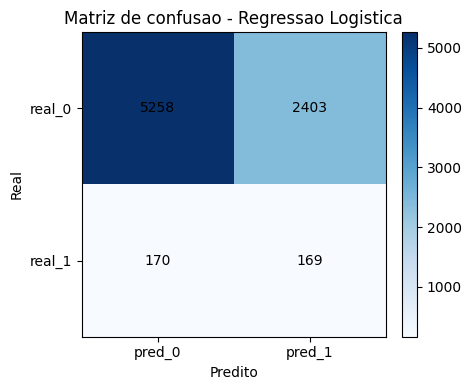

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_confusao_logreg.values, cmap='Blues')
ax.set_xticks(range(2), matriz_confusao_logreg.columns)
ax.set_yticks(range(2), matriz_confusao_logreg.index)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusao - Regressao Logistica')

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_confusao_logreg.iloc[i, j], ha='center', va='center')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


#### Item 6 - Conclusao da avaliacao Regressao Logistica

A conclusao abaixo compara os cenarios de idade e escala, sintetiza o tuning com GridSearchCV e as principais metricas da Regressao Logistica tunada. Esta etapa nao exporta arquivos; os resultados permanecem documentados no notebook.


In [10]:
melhor_cenario = comparacao_cenarios_logreg.iloc[0]
segundo_cenario = comparacao_cenarios_logreg.iloc[1]

conclusao_logreg = pd.DataFrame([
    {
        'aspecto': 'melhor_cenario_validacao',
        'conclusao': f"idade={melhor_cenario['idade']}, escala={melhor_cenario['escala']}, C={melhor_cenario['C']}, class_weight={melhor_cenario['class_weight']}",
    },
    {
        'aspecto': 'comparacao_idade_escala',
        'conclusao': f"Melhor F1 de validacao={melhor_cenario['f1']} contra {segundo_cenario['f1']} do segundo melhor cenario ({segundo_cenario['idade']} + {segundo_cenario['escala']}).",
    },
    {
        'aspecto': 'tuning_gridsearch',
        'conclusao': f"Melhor F1 medio no CV={metricas_teste_logreg['melhor_f1_cv']} com parametros {metricas_teste_logreg['melhores_parametros']}",
    },
    {
        'aspecto': 'amostra_utilizada',
        'conclusao': f"{metricas_teste_logreg['linhas_treino_usadas']} registros de treino e {metricas_teste_logreg['linhas_teste_avaliadas']} registros de teste",
    },
    {
        'aspecto': 'desempenho_teste',
        'conclusao': f"accuracy={metricas_teste_logreg['accuracy']}, balanced_accuracy={metricas_teste_logreg['balanced_accuracy']}, roc_auc={metricas_teste_logreg['roc_auc']}",
    },
    {
        'aspecto': 'classe_positiva',
        'conclusao': f"precision={metricas_teste_logreg['precision']}, recall={metricas_teste_logreg['recall']} e f1={metricas_teste_logreg['f1']}",
    },
    {
        'aspecto': 'interpretacao',
        'conclusao': 'A Regressao Logistica e um baseline linear interpretavel. O uso de class_weight balanced ajuda a compensar o desbalanceamento, mas o resultado deve ser analisado junto com precision, recall, F1 e ROC AUC.',
    },
    {
        'aspecto': 'decisao',
        'conclusao': 'A Regressao Logistica deve ser comparada aos baselines KNN, SVM e Random Forest antes de qualquer escolha de modelo final.',
    },
    {
        'aspecto': 'proximos_passos',
        'conclusao': 'Avaliar ajuste de threshold, calibracao de probabilidades, regularizacao mais ampla e comparacao consolidada com os demais algoritmos.',
    },
])


class TabelaHTML(str):
    def _repr_html_(self):
        return str(self)

estilo_tabela_conclusao = '''
<style>
.tabela-conclusao-logreg {
    width: 100%;
    table-layout: fixed;
    border-collapse: collapse;
}
.tabela-conclusao-logreg th,
.tabela-conclusao-logreg td {
    text-align: left;
    vertical-align: top;
    white-space: normal;
    word-wrap: break-word;
    overflow-wrap: anywhere;
    font-size: 13px;
    line-height: 1.35;
    padding: 8px 10px;
}
.tabela-conclusao-logreg th:first-child,
.tabela-conclusao-logreg td:first-child {
    width: 22%;
    font-weight: 600;
}
.tabela-conclusao-logreg th:nth-child(2),
.tabela-conclusao-logreg td:nth-child(2) {
    width: 78%;
}
</style>
'''

tabela_conclusao_html = conclusao_logreg.to_html(
    index=False,
    escape=True,
    classes='tabela-conclusao-logreg',
)

TabelaHTML(estilo_tabela_conclusao + tabela_conclusao_html)


aspecto,conclusao
melhor_cenario_validacao,"idade=num, escala=normalizacao, C=0.1, class_weight=balanced"
comparacao_idade_escala,Melhor F1 de validacao=0.1028 contra 0.1022 do segundo melhor cenario (num + padronizacao).
tuning_gridsearch,"Melhor F1 medio no CV=0.1146 com parametros {'logreg__C': 1.0, 'logreg__class_weight': 'balanced', 'preprocessamento__idade__scaler': StandardScaler()}"
amostra_utilizada,12000 registros de treino e 8000 registros de teste
desempenho_teste,"accuracy=0.6784, balanced_accuracy=0.5924, roc_auc=0.6348"
classe_positiva,"precision=0.0657, recall=0.4985 e f1=0.1161"
interpretacao,"A Regressao Logistica e um baseline linear interpretavel. O uso de class_weight balanced ajuda a compensar o desbalanceamento, mas o resultado deve ser analisado junto com precision, recall, F1 e ROC AUC."
decisao,"A Regressao Logistica deve ser comparada aos baselines KNN, SVM e Random Forest antes de qualquer escolha de modelo final."
proximos_passos,"Avaliar ajuste de threshold, calibracao de probabilidades, regularizacao mais ampla e comparacao consolidada com os demais algoritmos."


---

## Resumo final da Parte 6

Este notebook treina e avalia um baseline de Regressao Logistica usando as bases encoded finais da Parte 2:

- `bases/treino/x_encoded.parquet`
- `bases/treino/y.parquet`
- `bases/teste/x_encoded.parquet`
- `bases/teste/y.parquet`

Como a Regressao Logistica e um modelo linear sensivel a escala, a Parte 6 compara `CO_IDADE_PACIENTE_CAP` e `CO_IDADE_PACIENTE_NUM`, cada uma com padronizacao e normalizacao. Apenas a coluna numerica de idade do cenario e escalada; as dummies categoricas permanecem como `0/1`.

A avaliacao compara os cenarios por F1 e balanced accuracy na validacao, refina o melhor cenario com GridSearchCV e depois avalia o estimador tunado na amostra de teste. A Regressao Logistica fica registrada como baseline linear interpretavel para comparacao com KNN, SVM e Random Forest.
